In [ ]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from main import PROJECT_DIR, get_combined_df


In [5]:
# Dataset
df = get_combined_df()
df.head()

,flight_id,before_after,date_diff,flight_length,label,num_flights_before,volt1_mean,volt1_std,volt1_min,volt1_max,volt1_p25,volt1_p75,volt2_mean,volt2_std,volt2_min,volt2_max,volt2_p25,volt2_p75,amp1_mean,amp1_std,amp1_min,amp1_max,amp1_p25,amp1_p75,amp2_mean,amp2_std,amp2_min,amp2_max,amp2_p25,amp2_p75,FQtyL_mean,FQtyL_std,FQtyL_min,FQtyL_max,FQtyL_p25,FQtyL_p75,FQtyL_start,FQtyL_end,FQtyL_consumed,FQtyL_rate,...,E1_CHT_EGT_ratio_std,E1_CHT1_EGT1_ratio_mean,E1_CHT4_EGT4_ratio_mean,E1_CHT_OAT_diff_mean,E1_CHT_OAT_ratio_mean,E1_CHT_cv,E1_EGT_cv,E1_CHT1_deviation,E1_CHT4_deviation,E1_EGT4_deviation,E1_CHT_range_iqr,E1_EGT_range_iqr,E1_specific_fuel_consumption,E1_power_metric,E1_FFlow_RPM_ratio_std,E1_OilP_RPM_ratio,electrical_load_variance,volt1_amp1_stability,amp1_negative_ratio,E1_CHT_max_rate_change,E1_CHT_acceleration,E1_EGT_max_rate_change,E1_FFlow_acceleration,E1_OilP_instability,E1_OilT_climb_rate,E1_OilT_descend_rate,high_power_duration_ratio,high_temp_duration_ratio,E1_CHT_threshold,E1_OilT_threshold,E1_CHT_cruise_stability,E1_RPM_cruise_stability,E1_OilP_RPM_corr,E1_CHT2_CHT4_corr,E1_EGT1_EGT3_corr,fuel_imbalance_trend,E1_CHT_p90_p10_spread,E1_EGT_p90_p10_spread,E1_CHT_asymmetry,E1_CHT_spread_p90
0,1,before,-1,4723.0,intake gasket leak/damage,-1,28.780796,4.712894e-02,28.7,29.3,28.8,28.8,NaN,NaN,NaN,NaN,NaN,NaN,1.799555,1.802312,-0.8,9.6,0.8,2.00,NaN,NaN,NaN,NaN,NaN,NaN,50.308738,4.939421,35.21,54.00,46.15,54.0000,54.00,41.21,12.79,0.002708,...,NaN,0.289607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.536424,0.003560,15892.533613,0.001070,0.038938,NaN,1.683444e-02,0.000212,NaN,NaN,69.03,0.147227,0.087651,0.031250,0.032627,0.247724,NaN,NaN,0.0,NaN,135.360540,0.928213,NaN,0.991630,0.000837,NaN,442.29050,NaN,NaN
1,2,before,-2,4649.0,intake gasket leak/damage,-2,27.831276,7.633934e-01,25.0,28.2,28.1,28.1,27.902302,0.75904,25.1,28.2,28.10,28.2,0.901119,3.241838,-13.2,15.7,0.5,1.30,0.009421,0.168589,-1.1,1.3,-0.1,0.0,18.451667,1.991954,14.12,22.58,17.00,19.9200,21.15,15.80,5.35,0.001151,...,0.035603,0.240109,0.216159,259.444311,13.812147,0.158062,0.139468,6.859669,-15.448587,23.120871,5.692856,3.966741,0.004079,17201.156226,0.001308,0.035264,3.332015,4.015496e-01,0.087976,2.32,0.193674,82.90,0.336434,0.344230,0.034125,0.035514,0.249731,0.248441,0.0,0.0,20.371883,222.531540,0.973778,0.921516,0.996713,0.000105,97.8160,508.72900,0.639139,40.692
2,3,same,0,40.0,intake gasket leak/damage,0,24.900000,3.600403e-15,24.9,24.9,24.9,24.9,NaN,NaN,NaN,NaN,NaN,NaN,-8.202632,0.071610,-8.4,-8.1,-8.2,-8.20,NaN,NaN,NaN,NaN,NaN,NaN,43.662750,0.057423,43.57,43.76,43.61,43.7125,43.60,43.64,-0.04,-0.001000,...,NaN,0.988797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.960000,NaN,NaN,NaN,NaN,NaN,-4.998733e-16,1.000000,NaN,NaN,0.81,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.981069,-0.002973,NaN,0.12425,NaN,NaN
3,4,before,0,14.0,intake gasket leak/damage,0,25.400000,3.697782e-15,25.4,25.4,25.4,25.4,25.500000,0.00000,25.5,25.5,25.50,25.5,-10.684615,0.037553,-10.7,-10.6,-10.7,-10.70,0.000000,0.000000,-0.0,-0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000273,0.984173,1.008074,59.390385,2.966569,0.001326,0.001080,-5.356538,6.541923,5.443077,76.500000,74.666667,NaN,NaN,NaN,NaN,0.037553,-3.818202e-16,1.000000,0.09,0.053157,0.11,0.000000,0.003333,NaN,NaN,0.000000,0.230769,0.0,0.0,NaN,NaN,NaN,0.982345,0.961690,NaN,0.2940,0.23050,0.163636,11.910
4,5,same,0,683.0,intake gasket leak/damage,0,26.945095,1.271312e+00,24.6,28.1,25.5,27.9,26.950659,1.25279,24.6,28.1,25.55,27.9,-1.644363,5.390739,-17.7,6.1,-6.9,1.75,0.150805,0.208215,-1.0,0.6,-0.0,0.3,22.427643,0.472094,20.97,23.94,22.15,22.6800,22.15,22.43,-0.28,-0.000410,...,0.077475,0.258959,0.255352,242.435359,9.135134,0.275134,0.137465,-2.759034,-1.922650,1.305132,2.303781,5.078815,0.002462,4082.625744,0.000874,0.054182,5.528257,-1.972974e+00,0.380673,1.98,0.181840,39.06,0.258335,0.269062,NaN,NaN,0.250366,0.250366,0.0,0.0,73.223720,451.412721,0.941312,0.997425,0.998258,-0.000924,195.6855,4

In [6]:
conn = sqlite3.connect(f"{PROJECT_DIR}/data/SQLEngineeredFlightData.db")

In [ ]:
# Only run this once to create the table, afterwards comment it out, or it will overwrite the data
# This has already been done, so no need to run again
# df.to_sql("flight_features", conn, if_exists="replace", index=False)

In [7]:
cursor = conn.cursor()

In [8]:
cursor.execute("SELECT * FROM flight_features LIMIT 7;")
results = cursor.fetchall()
for row in results:
    print(row)

(1, 'before', -1, 4723.0, 'intake gasket leak/damage', -1, 28.78079610417108, 0.047128935063140455, 28.7, 29.3, 28.8, 28.8, None, None, None, None, None, None, 1.7995553673512596, 1.8023120984168748, -0.8, 9.6, 0.8, 2.0, None, None, None, None, None, None, 50.308738090196904, 4.939421329949509, 35.21, 54.0, 46.15, 54.0, 54.0, 41.21, 12.79, 0.002708024560660597, 48.65176794410332, 6.387320716343605, 34.82, 54.0, 41.385000000000005, 54.0, 54.0, 37.26, 16.740000000000002, 0.0035443573999576544, 1.7290048697861526, 15.86, 7.006622909167901, 3.8410651019211275, 16.26, 1.41, 2.66, 9.745000000000001, 1967.9564471734068, 644.351258391936, 816.5, 2694.5, 1086.25, 2478.2, 138.07419648528477, 29.844460419143065, 62.99, 172.57, 0.02320135507092949, 118.46000000000001, 162.87, 76.62867668854541, 11.219448738396162, 48.78, 69.55, 82.48, None, None, None, None, None, 0.06539911073470252, 345.2258268049968, 55.167664768901176, 134.4, 443.28, 313.03, 386.83000000000004, None, None, None, None, None, No

In [9]:
# Print the column names
cursor.execute("PRAGMA table_info(flight_features);")
columns = cursor.fetchall()
column_names = [column[1] for column in columns]
print(column_names)

['flight_id', 'before_after', 'date_diff', 'flight_length', 'label', 'num_flights_before', 'volt1_mean', 'volt1_std', 'volt1_min', 'volt1_max', 'volt1_p25', 'volt1_p75', 'volt2_mean', 'volt2_std', 'volt2_min', 'volt2_max', 'volt2_p25', 'volt2_p75', 'amp1_mean', 'amp1_std', 'amp1_min', 'amp1_max', 'amp1_p25', 'amp1_p75', 'amp2_mean', 'amp2_std', 'amp2_min', 'amp2_max', 'amp2_p25', 'amp2_p75', 'FQtyL_mean', 'FQtyL_std', 'FQtyL_min', 'FQtyL_max', 'FQtyL_p25', 'FQtyL_p75', 'FQtyL_start', 'FQtyL_end', 'FQtyL_consumed', 'FQtyL_rate', 'FQtyR_mean', 'FQtyR_std', 'FQtyR_min', 'FQtyR_max', 'FQtyR_p25', 'FQtyR_p75', 'FQtyR_start', 'FQtyR_end', 'FQtyR_consumed', 'FQtyR_rate', 'fuel_imbalance_mean', 'fuel_imbalance_max', 'E1_FFlow_mean', 'E1_FFlow_std', 'E1_FFlow_max', 'E1_FFlow_min', 'E1_FFlow_p25', 'E1_FFlow_p75', 'E1_RPM_mean', 'E1_RPM_std', 'E1_RPM_min', 'E1_RPM_max', 'E1_RPM_p25', 'E1_RPM_p75', 'E1_OilT_mean', 'E1_OilT_std', 'E1_OilT_min', 'E1_OilT_max', 'E1_OilT_rate', 'E1_OilT_p25', 'E1_OilT

In [10]:
cursor.execute("SELECT DISTINCT label FROM flight_features;")
unique_labels = cursor.fetchall()
print(unique_labels)

[('intake gasket leak/damage',), ('engine need repair/reinstall/clean',), ('engine run rough',), ('baffle plug need repair/replace',), ('baffle bracket loose/damage',), ('rocker cover leak/loose/damage',), ('oil cooler need maintenance',), ('engine failure/fire/time out',), ('baffle screw miss/loose',), ('pilot/in-flight noticed issue',), ('aircraft start/external issue',), ('cowling miss/loose/damage',), ('engine/propeller overspeed or damage',), ('engine seal/tube/bolt loose or damage',), ('cylinder crack/fail/need part repair',), ('baffle tie/tie rod loose or damage',), ('oil leak/pressure issue',), ('drain line/tube damage',), ('baffle mount loose/damage',), ('baffle spring damage',), ('cylinder compression issue',), ('intake tube/bolt/seal/boot loose or damage',), ('engine idle/rpm issue',), ('engine crankcase/crankshaft/firewall near repair',), ('oil dipstick/tube need repair',), ('oil return line issue',), ('mixture fail/need adjust',), ('spark plug need repair/replace',), ('cyl

In [11]:
cursor.execute("SELECT DISTINCT before_after FROM flight_features;")
unique_before_after = cursor.fetchall()
print(unique_before_after)

[('before',), ('same',), ('after',)]


In [12]:
cursor.execute(
    "SELECT * FROM flight_features WHERE label='intake gasket leak/damage' and before_after= 'before' LIMIT 5;"
)
results = cursor.fetchall()
for row in results:
    print(row)

(1, 'before', -1, 4723.0, 'intake gasket leak/damage', -1, 28.78079610417108, 0.047128935063140455, 28.7, 29.3, 28.8, 28.8, None, None, None, None, None, None, 1.7995553673512596, 1.8023120984168748, -0.8, 9.6, 0.8, 2.0, None, None, None, None, None, None, 50.308738090196904, 4.939421329949509, 35.21, 54.0, 46.15, 54.0, 54.0, 41.21, 12.79, 0.002708024560660597, 48.65176794410332, 6.387320716343605, 34.82, 54.0, 41.385000000000005, 54.0, 54.0, 37.26, 16.740000000000002, 0.0035443573999576544, 1.7290048697861526, 15.86, 7.006622909167901, 3.8410651019211275, 16.26, 1.41, 2.66, 9.745000000000001, 1967.9564471734068, 644.351258391936, 816.5, 2694.5, 1086.25, 2478.2, 138.07419648528477, 29.844460419143065, 62.99, 172.57, 0.02320135507092949, 118.46000000000001, 162.87, 76.62867668854541, 11.219448738396162, 48.78, 69.55, 82.48, None, None, None, None, None, 0.06539911073470252, 345.2258268049968, 55.167664768901176, 134.4, 443.28, 313.03, 386.83000000000004, None, None, None, None, None, No

In [13]:
conn.close()

### Classifier 

Idea behind this:
I want to create a binary classification model that basically focuses on one label. for that label we create a model that tells us if the flight needs maintenance on that label or not. (very similar to logisitic regression but this will focus on one label at a time and tell us if it needs maintenance, using SQL)

first we take our split sets for our X_train, we have all features, but filtered down to only the data with our label and remove any data where before_after is 'same' 

for Y_train, we have the before_after column, again only for our label 

if before_after is before, encode classifier as "1" needs maintenance 

if before_after is after, encode classifier as "0" does not need maintenance 

using SQL commands for all filtering and any use of data

In [98]:
conn = sqlite3.connect(f"{PROJECT_DIR}/data/TrainTestSplitData.db")

X_train = pd.read_sql("SELECT * FROM X_train", conn)
y_train = pd.read_sql(
    "SELECT target FROM y_train", conn
)  # this is 1/0, pre/post maintenance
X_test = pd.read_sql("SELECT * FROM X_test", conn)
y_test = pd.read_sql("SELECT target FROM y_test", conn)

In [55]:
y_train["target"].unique()

array([ 0.,  1., nan])

In [56]:
X_train["label"].unique()

array(['baffle seal loose/damage', 'rocker cover leak/loose/damage',
       'baffle spring damage', 'intake gasket leak/damage',
       'pilot/in-flight noticed issue',
       'intake tube/bolt/seal/boot loose or damage',
       'baffle tie/tie rod loose or damage',
       'engine need repair/reinstall/clean', 'engine run rough',
       'cylinder/exhaust push rod/tube damage',
       'induction damage/hardware fail', 'baffle screw miss/loose',
       'baffle crack/damage/loose/miss', 'engine failure/fire/time out',
       'baffle plug need repair/replace', 'oil cooler need maintenance',
       'cowling miss/loose/damage', 'engine idle/rpm issue',
       'oil dipstick/tube need repair', 'cylinder compression issue',
       'baffle rivet loose/miss/damage',
       'cylinder head/exhaust gas temperature issue',
       'baffle bracket loose/damage',
       'cylinder crack/fail/need part repair',
       'aircraft start/external issue',
       'engine/propeller overspeed or damage', 'oil lea

In [99]:
### Change Label Here ###
# label = "intake gasket leak/damage"
# label = "rocker cover leak/loose/damage"
# label = "intake tube/bolt/seal/boot loose or damage"
# label = "baffle crack/damage/loose/miss"
label = "baffle plug need repair/replace"
#########################

Now, let's filter using SQL. We want to keep rows that match our target label, "oil leak/pressure issue."
We also drop rows that are not "before" or "after" so we can accurately train our model on it and not get confused.
- before = 1 = needs maintenance
- after = 0 = does not need

In [100]:
# Filter X_train and y_train
y_test = y_test.squeeze()  # Returned dimensions (n,1) not (n,) so remove

mask_train = (X_train["label"] == label) & (X_train["before_after"] != "same")
X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train].reset_index(drop=True)

# Filter X_test and y_test
mask_test = (X_test["label"] == label) & (X_test["before_after"] != "same")
X_test = X_test.loc[mask_test]
y_test = y_test.loc[mask_test].reset_index(drop=True)

In [101]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((467, 210), (467, 1), (117, 210), (117,))

Move to pd dataframe and follow accordingly...

In [102]:
# Separate target and features
not_features = ["label", "before_after", "date_diff", "flight_id"]

X_train = X_train.drop(columns=not_features)
X_test = X_test.drop(columns=not_features)

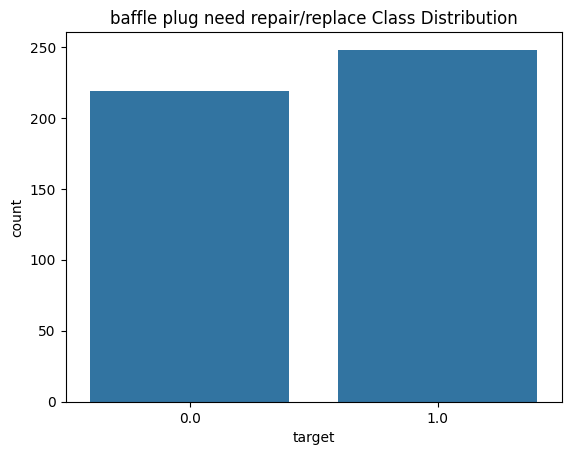

In [103]:
# Class Distribution
sns.barplot(data=y_train.value_counts().to_frame(), x="target", y="count")
plt.title(f"{label} Class Distribution");


In [104]:
# standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model (Logic taken from logisticRegression model notebook in src folder)
C = 0.1
max_iter = 50_000
random_state = 42

clf = LogisticRegression(C=C, max_iter=max_iter, random_state=random_state)

# Cross-Validation
cv = 5
scoring = "roc_auc"

cv_scores = cross_val_score(
    clf, X_train_scaled, y_train.values.reshape(-1), cv=cv, scoring=scoring
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", np.mean(cv_scores))


CV ROC-AUC scores: [0.98090909 0.99363636 0.99072356 0.99397032 0.99534884]
Mean ROC-AUC: 0.9909176338611555


In [105]:
# Train model
clf.fit(X_train_scaled, y_train.values.reshape(-1))

# Now on Test set
print("Accuracy for predicting maintenance for label:", label)
print("Test Accuracy:", clf.score(X_test_scaled, y_test))


Accuracy for predicting maintenance for label: baffle plug need repair/replace
Test Accuracy: 0.9572649572649573


Now that we have our model, we can create a SQL table and store our predictions from our test set to observe

In [ ]:
# Drop table if already exists
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS predictions_LR;")
conn.commit()


In [632]:
cursor.execute("""
CREATE TABLE predictions_LR (
    flight_id INTEGER,
    label TEXT,
    predicted_flag INTEGER,
    confidence REAL
);
""")
conn.commit()


In [106]:
y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[
    :, 1
]  # Want to check confidence for Probability of predicting class 1


We will create a dataframe to insert to the SQL table, then join it with original data to compare by flight_id

In [107]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94        44
         1.0       0.97      0.96      0.97        73

    accuracy                           0.96       117
   macro avg       0.95      0.96      0.95       117
weighted avg       0.96      0.96      0.96       117



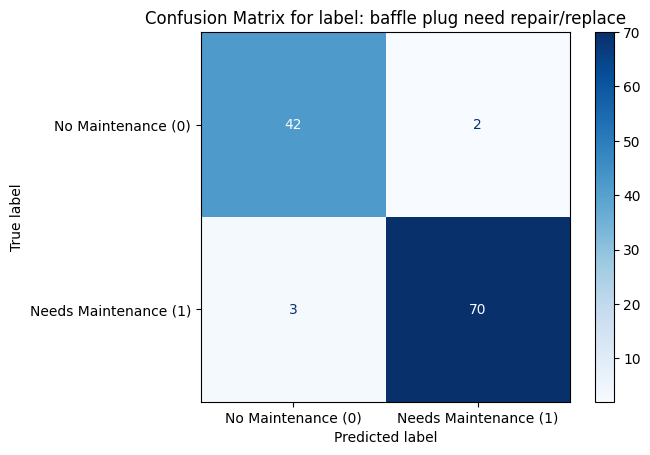

In [108]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["No Maintenance (0)", "Needs Maintenance (1)"]
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix for label: {label}")
plt.show()

In [ ]:
results_df = pd.DataFrame(
    {
        "flight_id": X_test.index,
        "label": label,
        "true_label": y_test.values,
        "predicted_flag": y_pred,
        "confidence": y_prob,
    }
)

Join predictions with original by flight_id

In [636]:
cursor.execute("DROP TABLE IF EXISTS predictions_LR;")
conn.commit()


In [ ]:
# Join predictions with original by flight_id
results_df.to_sql("predictions_LR", conn, if_exists="append", index=False)


117

In [ ]:
# See row info from table
cursor.execute("SELECT * FROM predictions_LR;")
rows = cursor.fetchall()

for row in rows:
    print(row)


(42, 'baffle plug need repair/replace', 1.0, 1.0, 0.8405167818354887)
(56, 'baffle plug need repair/replace', 1.0, 1.0, 0.9363344970517911)
(68, 'baffle plug need repair/replace', 1.0, 1.0, 0.7713245059765252)
(76, 'baffle plug need repair/replace', 0.0, 0.0, 0.11028735586068288)
(84, 'baffle plug need repair/replace', 1.0, 1.0, 0.9674295798877385)
(95, 'baffle plug need repair/replace', 1.0, 1.0, 0.961028040149089)
(104, 'baffle plug need repair/replace', 0.0, 0.0, 0.1289537501177996)
(142, 'baffle plug need repair/replace', 1.0, 1.0, 0.6004747772808703)
(156, 'baffle plug need repair/replace', 1.0, 1.0, 0.9073145905404894)
(164, 'baffle plug need repair/replace', 1.0, 1.0, 0.869657605880936)
(215, 'baffle plug need repair/replace', 1.0, 1.0, 0.7229392911921311)
(217, 'baffle plug need repair/replace', 1.0, 1.0, 0.9396898867429687)
(241, 'baffle plug need repair/replace', 0.0, 0.0, 0.04024368085966675)
(253, 'baffle plug need repair/replace', 0.0, 0.0, 0.0533797841788474)
(282, 'baffl

In [639]:
df_pred = pd.read_sql_query("SELECT * FROM predictions_LR;", conn)
df_pred.head()

,flight_id,label,true_label,predicted_flag,confidence
0,42,baffle plug need repair/replace,1.0,1.0,0.840517
1,56,baffle plug need repair/replace,1.0,1.0,0.936334
2,68,baffle plug need repair/replace,1.0,1.0,0.771325
3,76,baffle plug need repair/replace,0.0,0.0,0.110287
4,84,baffle plug need repair/replace,1.0,1.0,0.967430


In [640]:
conn.close()